# ME 144/244: Modeling, Simulation, and Digital Twins of Drone-Based Systems 
## Project 3: Swarm
## Spring 2026 Semester
### GSI - Tommy Hosmer

## Notebook to generate figures

In [1]:
import pickle
from simulation import Simulation
from animation import Animation
from swarmga import SwarmGA

## Load the parameter values that define the GA and Simulation

In [2]:
with open('parameters.pkl', 'rb') as file:
    parameters = pickle.load(file)

# Run GA

In [3]:
swarmGA = SwarmGA(parameters)
swarmGA.initialize_special_params()
# Return dictionary of results
data = swarmGA.specialGA(print_statements=True)

Generation: 1
Best cost: 29.5
M*: [0.05 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.  ]
T*: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
L*: [0.8 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  

## Dump GA results into a pickle file

### This allows you to reuse data from the GA in the event you restart the notebook. With the data saved you can simply read the pkl and run the animations/plots when convenient

In [4]:
with open('ga_results.pkl', 'wb') as f:
        pickle.dump(data, f)

# Run Simulation with GA Results


In [5]:
# Run this cell in case of kernel restart and need GA data from pickle file
with open('ga_results.pkl', 'rb') as file:
    data = pickle.load(file)

In [6]:
LAM = data['best_p_strings'][0]
sim = Simulation(parameters=parameters, path_to_genes='')
PI, posData, tarData, obsData, counter, Mstar, Tstar, Lstar =  sim.run_simulation(True, LAM)

# Make Plots and Animations

In [7]:
animationObject = Animation(counter, tarData, posData, obsData, parameters)

# Question 1

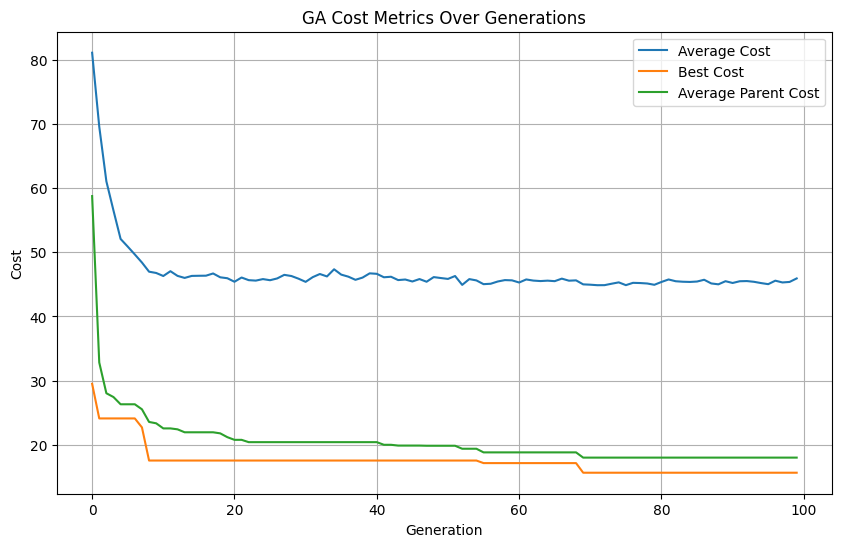

In [8]:
animationObject.plot_costs_over_generations('ga_results.pkl','figures')

## Question 2

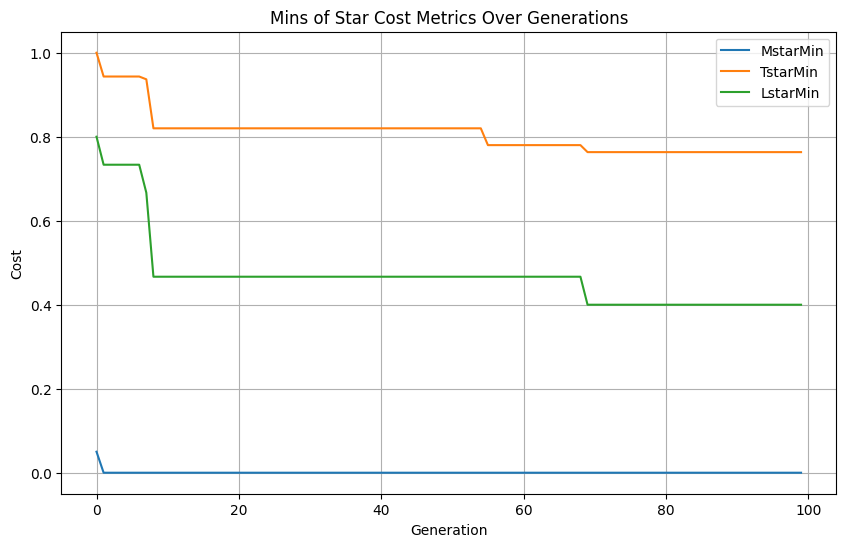

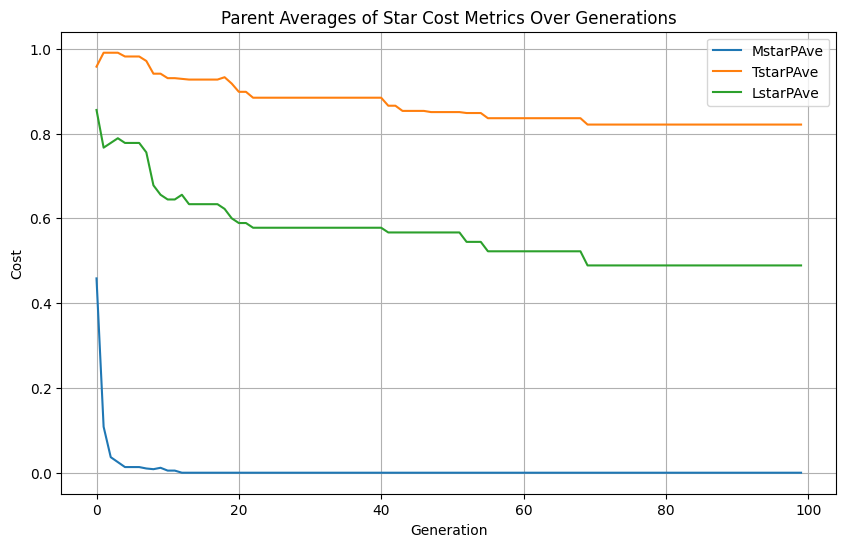

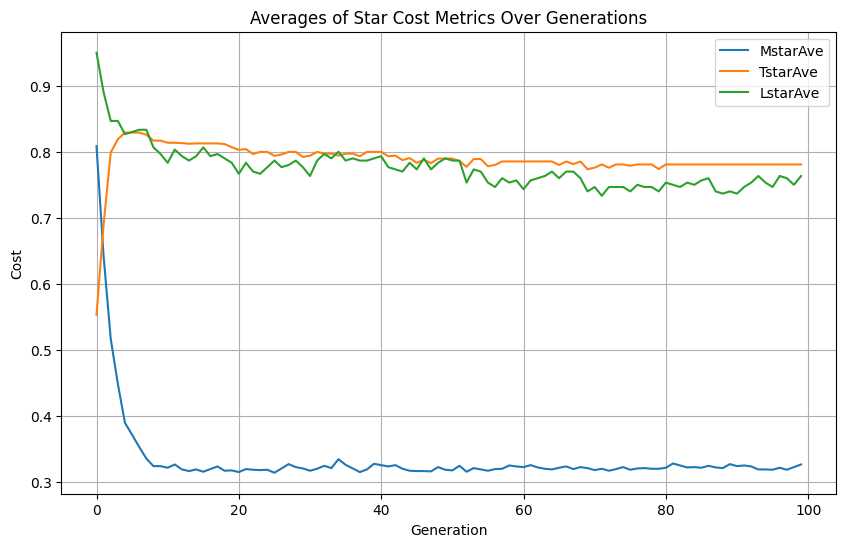

In [9]:
animationObject.plot_star_vals('ga_results.pkl','figures')

## Question 3

In [10]:
for i in range(4):
    res = []
    LAM = data['best_p_strings'][i]
    for j in LAM:
        res.append(float(round(j,3)))
    print(f'Lambda[{i}]: {res}')

    sim = Simulation(parameters=parameters, path_to_genes='')
    PI, _, _, _, _, _, _, _ =  sim.run_simulation(True, LAM)
    print(f'PI[{i}]: {float(round(PI,3))}\n')

Lambda[0]: [1.134, 1.887, 0.328, 1.553, 1.334, 0.547, 0.583, 0.717, 1.405, 0.206, 1.448, 1.184, 1.657, 1.07, 1.736]
PI[0]: 15.633

Lambda[1]: [1.134, 1.885, 0.329, 1.554, 1.334, 0.548, 0.583, 0.717, 1.374, 0.206, 1.44, 1.184, 1.657, 1.07, 1.736]
PI[1]: 17.133

Lambda[2]: [1.134, 1.889, 0.328, 1.553, 1.334, 0.544, 0.583, 0.717, 1.417, 0.206, 1.449, 1.184, 1.657, 1.07, 1.736]
PI[2]: 17.533

Lambda[3]: [1.135, 1.882, 0.329, 1.554, 1.334, 0.548, 0.583, 0.717, 1.37, 0.206, 1.44, 1.184, 1.656, 1.07, 1.737]
PI[3]: 17.833



## Question 5

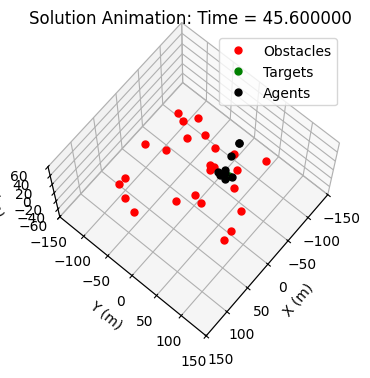

In [11]:
# Save this animation, then take screenshots
animationObject.animation('')

In [12]:
import os
import numpy as np
import cv2

# --- inputs ---
video_path = "15_agents_25_obs_100_tar.mp4"   # adjust if it's inside another folder
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

# --- open video ---
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_s = frame_count / fps

print(f"fps={fps:.3f}, frames={frame_count}, duration={duration_s:.3f} s")

# choose 5 evenly-spaced times INCLUDING endpoints
times = np.linspace(0, duration_s, 5)

# convert times -> frame indices (clamp to valid range)
frame_idxs = np.clip(np.round(times * fps).astype(int), 0, frame_count - 1)

saved = []
for k, (t, idx) in enumerate(zip(times, frame_idxs)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ok, frame_bgr = cap.read()
    if not ok:
        raise RuntimeError(f"Failed to read frame {idx} at time ~{t:.3f}s")

    # (optional) convert BGR->RGB if you plan to display; for saving with cv2 it's fine as BGR
    out_path = os.path.join(out_dir, f"frame_{k}_t_{t:06.2f}s.png")
    cv2.imwrite(out_path, frame_bgr)
    saved.append(out_path)

cap.release()

print("Saved:")
for p in saved:
    print(" ", p)

fps=60.000, frames=229, duration=3.817 s
Saved:
  figures/frame_0_t_000.00s.png
  figures/frame_1_t_000.95s.png
  figures/frame_2_t_001.91s.png
  figures/frame_3_t_002.86s.png
  figures/frame_4_t_003.82s.png


In [13]:
import pickle
import numpy as np

with open("ga_results.pkl", "rb") as f:
    ga_results = pickle.load(f)

# Inspect what keys exist
print(type(ga_results))
print(ga_results.keys())

<class 'dict'>
dict_keys(['best_cost', 'average_cost', 'parents_average_cost', 'best_p_strings', 'MstarMin', 'TstarMin', 'LstarMin', 'MstarPAve', 'TstarPAve', 'LstarPAve', 'MstarAve', 'TstarAve', 'LstarAve'])


In [14]:
import numpy as np

best_p = np.array(ga_results["best_p_strings"])  # shape should be (G, P, 15) OR (G, P, 16)
print("best_p shape:", best_p.shape)

# Flatten across generations
flat = best_p.reshape(-1, best_p.shape[-1])

# If last column is cost Π, separate it
if flat.shape[1] == 16:
    lambdas = flat[:, :15]
    pis = flat[:, 15]
else:
    lambdas = flat
    # If costs are not stored per-string, we need to recompute Π by rerunning simulation for each lambda
    pis = None

print("num candidates:", lambdas.shape[0])
print("pis stored?", pis is not None)

best_p shape: (6, 15)
num candidates: 6
pis stored? False


In [17]:
import pickle

# load parameters
with open("parameters.pkl", "rb") as f:
    parameters = pickle.load(f)

pis = []
for lam in lambdas:
    sim = Simulation(parameters, path_to_genes="")
    PI, *_ = sim.run_simulation(read_LAM=True, LAM=list(lam))
    pis.append(PI)

pis = np.array(pis)

idx = np.argsort(pis)[:4]
top4_lam = lambdas[idx]
top4_pi = pis[idx]

for k in range(4):
    print(f"\nDesign {k+1}: Pi={top4_pi[k]:.6f}")
    print(np.round(top4_lam[k], 2))


Design 1: Pi=15.633333
[1.13 1.89 0.33 1.55 1.33 0.55 0.58 0.72 1.41 0.21 1.45 1.18 1.66 1.07
 1.74]

Design 2: Pi=17.133333
[1.13 1.89 0.33 1.55 1.33 0.55 0.58 0.72 1.37 0.21 1.44 1.18 1.66 1.07
 1.74]

Design 3: Pi=17.533333
[1.13 1.89 0.33 1.55 1.33 0.54 0.58 0.72 1.42 0.21 1.45 1.18 1.66 1.07
 1.74]

Design 4: Pi=17.833333
[1.14 1.88 0.33 1.55 1.33 0.55 0.58 0.72 1.37 0.21 1.44 1.18 1.66 1.07
 1.74]
